13.13. Implement agglomerative clustering from scratch with single, complete, and Ward’s 
linkage. Test on three Gaussian blobs and Two Moons. Visualize the dendrograms and the 
resulting 2-cluster partitions. 

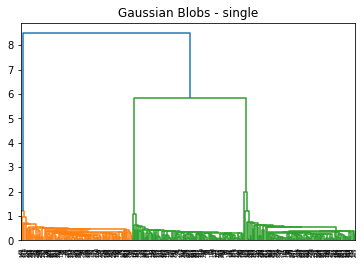

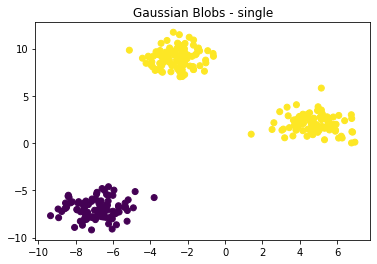

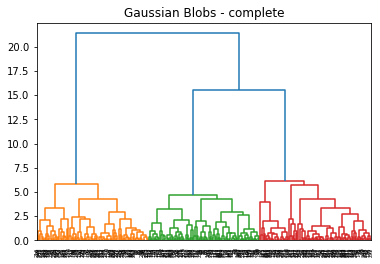

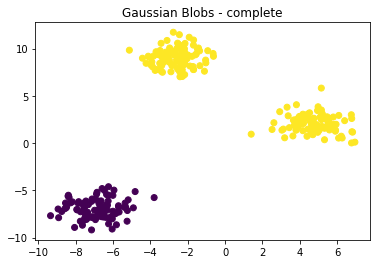

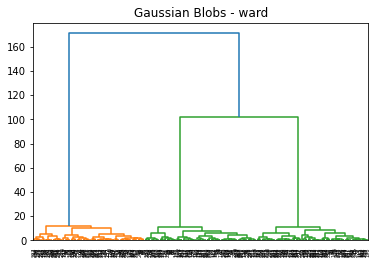

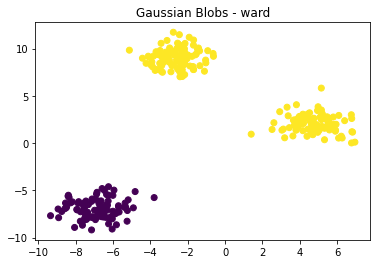

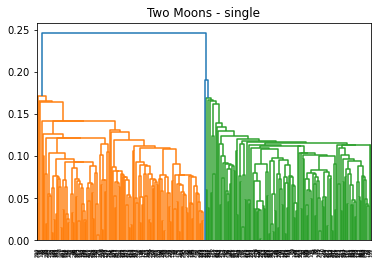

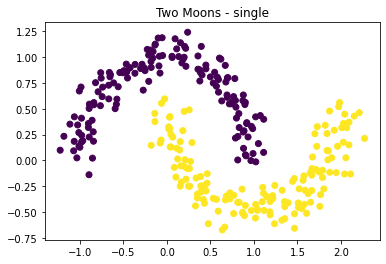

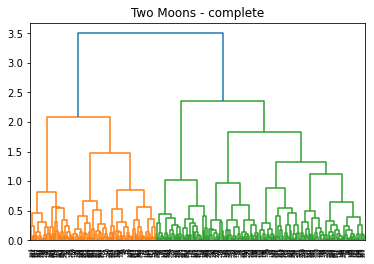

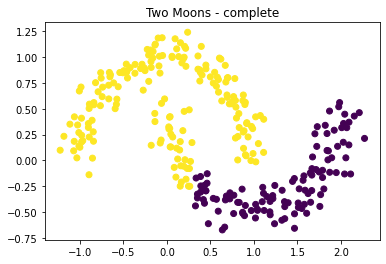

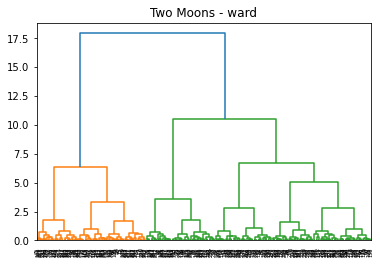

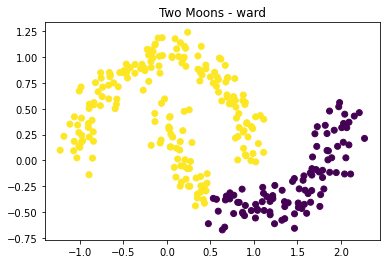

In [1]:
import matplotlib.pyplot as plt

from sklearn.datasets import make_blobs
from sklearn.datasets import make_moons

from scipy.cluster.hierarchy import (
    linkage,
    dendrogram,
    fcluster
)

# -----------------------------------
# Datasets
# -----------------------------------

X1, y1 = make_blobs(
    n_samples=300,
    centers=3,
    cluster_std=1,
    random_state=42
)

X2, y2 = make_moons(
    n_samples=300,
    noise=0.1,
    random_state=42
)

datasets = [
    (X1, "Gaussian Blobs"),
    (X2, "Two Moons")
]

methods = [
    'single',
    'complete',
    'ward'
]

# -----------------------------------
# Agglomerative Clustering
# -----------------------------------

for X, name in datasets:

    for method in methods:

        # Linkage matrix
        Z = linkage(
            X,
            method=method
        )

        # -------------------------
        # Dendrogram
        # -------------------------

        dendrogram(Z)

        plt.title(
            f"{name} - {method}"
        )

        plt.show()

        # -------------------------
        # 2-cluster partition
        # -------------------------

        labels = fcluster(
            Z,
            2,
            criterion='maxclust'
        )

        plt.scatter(
            X[:,0],
            X[:,1],
            c=labels
        )

        plt.title(
            f"{name} - {method}"
        )

        plt.show()

13.14. Implement DBSCAN from scratch. Test on Two Moons and concentric circles with varying 
ε. Plot the k-distance graph and show how diEerent ε choices aEect the results. 

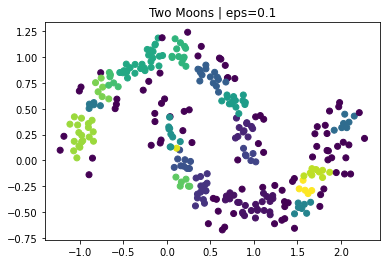

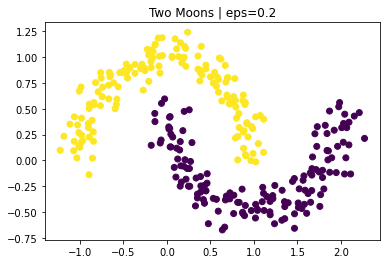

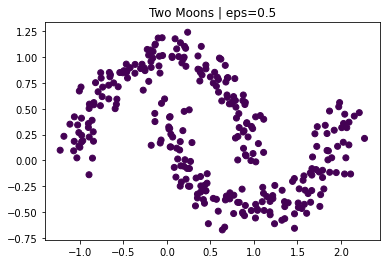

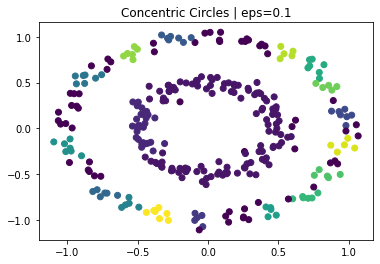

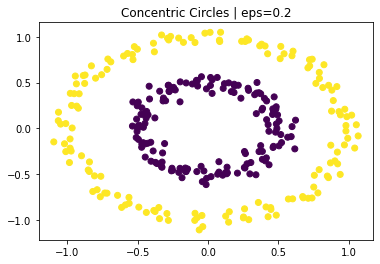

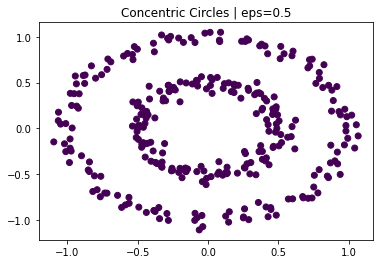

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_moons
from sklearn.datasets import make_circles
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors

# -----------------------------------
# Datasets
# -----------------------------------

X1, y1 = make_moons(
    n_samples=300,
    noise=0.1,
    random_state=42
)

X2, y2 = make_circles(
    n_samples=300,
    factor=0.5,
    noise=0.05,
    random_state=42
)

datasets = [
    (X1, "Two Moons"),
    (X2, "Concentric Circles")
]

eps_values = [0.1, 0.2, 0.5]

# -----------------------------------
# DBSCAN with varying epsilon
# -----------------------------------

for X, name in datasets:

    for eps in eps_values:

        model = DBSCAN(
            eps=eps,
            min_samples=5
        )

        labels = model.fit_predict(X)

        plt.scatter(
            X[:,0],
            X[:,1],
            c=labels
        )

        plt.title(
            f"{name} | eps={eps}"
        )

        plt.show()

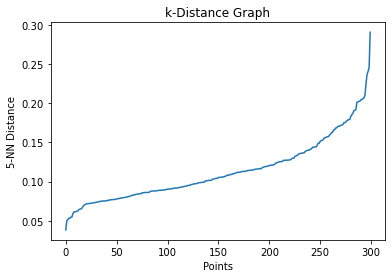

In [3]:
#k-Distance Graph
neighbors = NearestNeighbors(
    n_neighbors=5
)

neighbors.fit(X1)

distances, indices = \
neighbors.kneighbors(X1)

# Sort distances
distances = np.sort(
    distances[:,4]
)

plt.plot(distances)

plt.xlabel("Points")

plt.ylabel("5-NN Distance")

plt.title("k-Distance Graph")

plt.show()

13.15. Generate a dataset with three clusters of very diEerent densities: a tight cluster (100 
points, σ = 0.1), a medium cluster (100 points, σ = 0.5), and a diEuse cluster (100 points, σ = 2.0). 
Apply DBSCAN with several ε values. Document the varying-density problem.

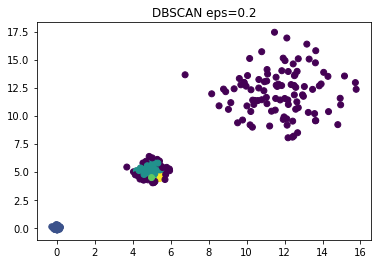

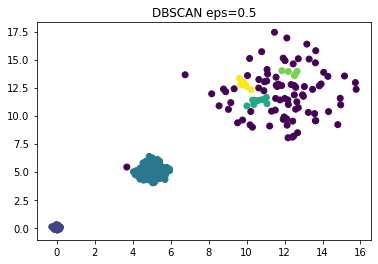

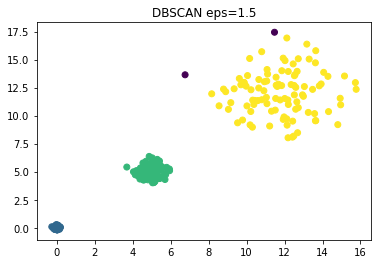

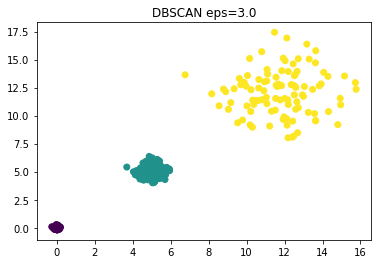

In [4]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_blobs
from sklearn.cluster import DBSCAN

# -----------------------------------
# Generate clusters
# -----------------------------------

X1, _ = make_blobs(
    n_samples=100,
    centers=[[0,0]],
    cluster_std=0.1,
    random_state=42
)

X2, _ = make_blobs(
    n_samples=100,
    centers=[[5,5]],
    cluster_std=0.5,
    random_state=42
)

X3, _ = make_blobs(
    n_samples=100,
    centers=[[12,12]],
    cluster_std=2.0,
    random_state=42
)

# Combine data
X = np.vstack([X1, X2, X3])

# -----------------------------------
# Try different epsilon values
# -----------------------------------

eps_values = [0.2, 0.5, 1.5, 3.0]

for eps in eps_values:

    model = DBSCAN(
        eps=eps,
        min_samples=5
    )

    labels = model.fit_predict(X)

    plt.scatter(
        X[:,0],
        X[:,1],
        c=labels
    )

    plt.title(
        f"DBSCAN eps={eps}"
    )

    plt.show()

13.16. Run K-Means (K = 3), Ward’s agglomerative (cut at 3), and DBSCAN on a dataset with 
overlapping clusters and noise. Compare silhouette scores and visual results. When do the 
methods agree? When do they disagree?

K-Means Silhouette Score = 0.5925869033585319


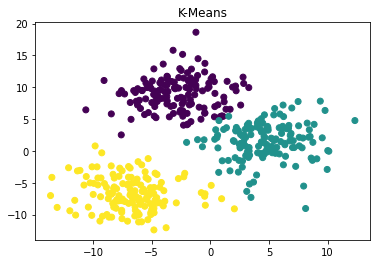

Ward Silhouette Score = 0.5825806994769196


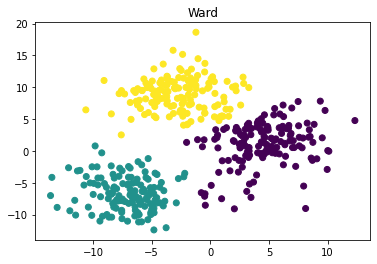

DBSCAN Silhouette Score = 0.21142542745853354


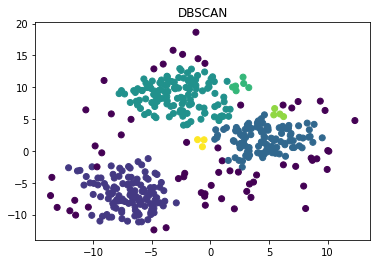

In [5]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_blobs
from sklearn.cluster import (
    KMeans,
    AgglomerativeClustering,
    DBSCAN
)

from sklearn.metrics import silhouette_score

# -----------------------------------
# Generate dataset
# -----------------------------------

X, y = make_blobs(
    n_samples=400,
    centers=3,
    cluster_std=2.5,
    random_state=42
)

# Add noise points
noise = np.random.uniform(
    low=-10,
    high=10,
    size=(40,2)
)

X = np.vstack([X, noise])

# -----------------------------------
# Models
# -----------------------------------

models = {
    "K-Means":
        KMeans(
            n_clusters=3,
            random_state=42
        ),

    "Ward":
        AgglomerativeClustering(
            n_clusters=3,
            linkage='ward'
        ),

    "DBSCAN":
        DBSCAN(
            eps=1.2,
            min_samples=5
        )
}

# -----------------------------------
# Train and Compare
# -----------------------------------

for name, model in models.items():

    labels = model.fit_predict(X)

    # Silhouette score
    score = silhouette_score(
        X,
        labels
    )

    print(
        name,
        "Silhouette Score =",
        score
    )

    # Visualization
    plt.scatter(
        X[:,0],
        X[:,1],
        c=labels
    )

    plt.title(name)

    plt.show()

13.17. Customer segmentation comparison: using the same synthetic customer data from 
Chapter 12 (4 features, 500 customers), apply hierarchical clustering (with dendrogram) and 
DBSCAN. Compare the three methods’ segmentations. Which customers are classified 
diEerently? What do the noise points tell you? 

K-Means Silhouette Score = 0.599592196935762


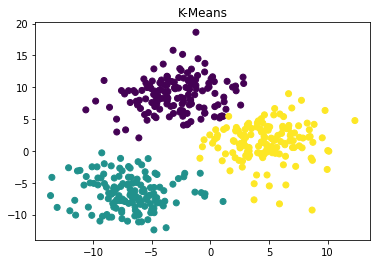

Ward Silhouette Score = 0.5808844135858562


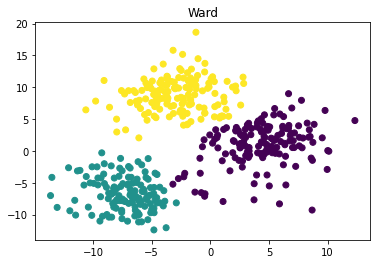

DBSCAN Silhouette Score = 0.2711283178733161


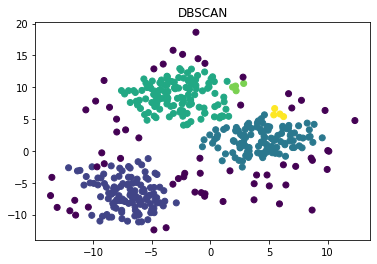

In [6]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_blobs
from sklearn.cluster import (
    KMeans,
    AgglomerativeClustering,
    DBSCAN
)

from sklearn.metrics import silhouette_score

# -----------------------------------
# Generate dataset
# -----------------------------------

X, y = make_blobs(
    n_samples=400,
    centers=3,
    cluster_std=2.5,
    random_state=42
)

# Add noise points
noise = np.random.uniform(
    low=-10,
    high=10,
    size=(40,2)
)

X = np.vstack([X, noise])

# -----------------------------------
# Models
# -----------------------------------

models = {
    "K-Means":
        KMeans(
            n_clusters=3,
            random_state=42
        ),

    "Ward":
        AgglomerativeClustering(
            n_clusters=3,
            linkage='ward'
        ),

    "DBSCAN":
        DBSCAN(
            eps=1.2,
            min_samples=5
        )
}

# -----------------------------------
# Train and Compare
# -----------------------------------

for name, model in models.items():

    labels = model.fit_predict(X)

    # Silhouette score
    score = silhouette_score(
        X,
        labels
    )

    print(
        name,
        "Silhouette Score =",
        score
    )

    # Visualization
    plt.scatter(
        X[:,0],
        X[:,1],
        c=labels
    )

    plt.title(name)

    plt.show()

13.18. Linkage sensitivity analysis: generate a dataset with two elongated Gaussian clusters. Run 
agglomerative clustering with all four linkage methods. Compare dendrograms and 2-cluster 
results. Which linkage works best for elongated clusters? Why? 

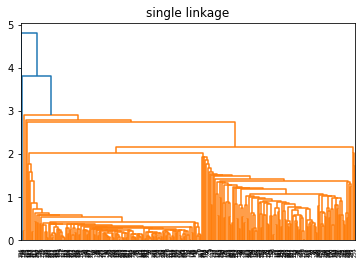

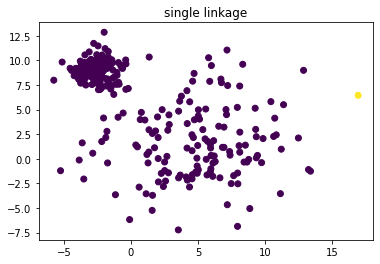

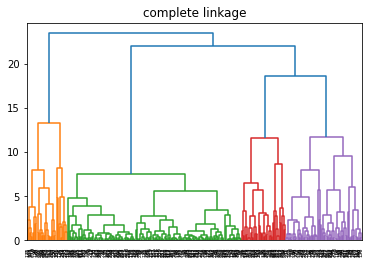

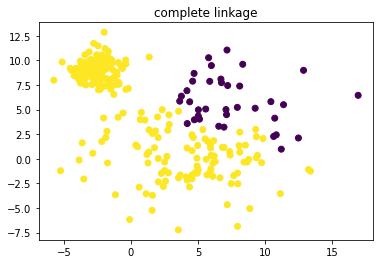

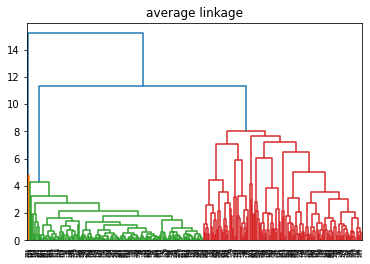

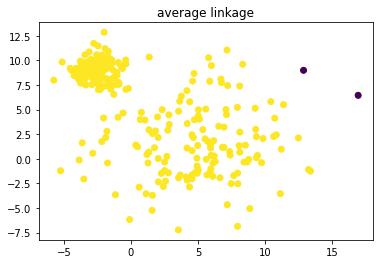

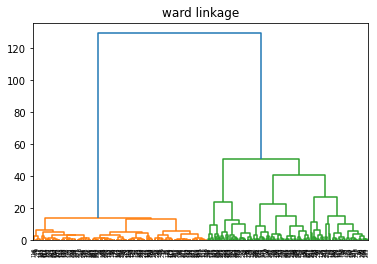

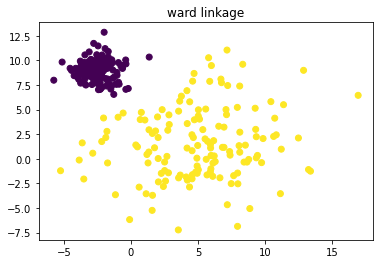

In [7]:
import matplotlib.pyplot as plt

from sklearn.datasets import make_blobs
from scipy.cluster.hierarchy import (
    linkage,
    dendrogram,
    fcluster
)

# -----------------------------------
# Generate elongated clusters
# -----------------------------------

X, y = make_blobs(
    n_samples=300,
    centers=2,
    cluster_std=[1,4],
    random_state=42
)

# -----------------------------------
# Linkage methods
# -----------------------------------

methods = [
    'single',
    'complete',
    'average',
    'ward'
]

# -----------------------------------
# Agglomerative clustering
# -----------------------------------

for method in methods:

    # Linkage matrix
    Z = linkage(
        X,
        method=method
    )

    # -------------------------
    # Dendrogram
    # -------------------------

    dendrogram(Z)

    plt.title(
        f"{method} linkage"
    )

    plt.show()

    # -------------------------
    # 2-cluster partition
    # -------------------------

    labels = fcluster(
        Z,
        2,
        criterion='maxclust'
    )

    plt.scatter(
        X[:,0],
        X[:,1],
        c=labels
    )

    plt.title(
        f"{method} linkage"
    )

    plt.show()